In [1]:
library(tidyverse)
library(scales)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [2]:
cell_types <- c("Cardiomyocyte", "Fibroblast", "Endothelial", "Epicardial", "Lymphoid", "Myeloid", "Neuronal", "Pericyte", "vSMC")

In [3]:
res_list = list()

for (cell_type in cell_types) {
    res_df = read.csv(paste0("intersecting_SNPs/", cell_type, "_loci_intersections.csv"))
    filt_res_df = res_df[, c("name", "TargetGene", "lead_SNP", "disease", "candidate_SNP", "RNA_pseudobulkTPM",
                             "CellType", "prioritized_gene", "E2G.Score", "locus")]
    res_list[[cell_type]] <- filt_res_df
}

In [4]:
colnames(res_df)

[1] "chr"                       "start"                    
 [3] "end"                       "name"                     
 [5] "class"                     "TargetGene"               
 [7] "TargetGeneTSS"             "TargetGeneIsExpressed"    
 [9] "TargetGeneEnsembl_ID"      "isSelfPromoter"           
[11] "CellType"                  "distance"                 
[13] "normalizedATAC_prom"       "ABC.Score"                
[15] "normalizedATAC_enh"        "numCandidateEnhGene"      
[17] "numTSSEnhGene"             "numNearbyEnhancers"       
[19] "ubiqExpressed"             "RNA_meanLogNorm"          
[21] "RNA_pseudobulkTPM"         "RNA_percentCellsDetected" 
[23] "Kendall"                   "ARC.E2G.Score"            
[25] "E2G.Score"                 "E2G.Score.qnorm"          
[27] "E2G.Score.qnorm.ignoreTPM" "region"                   
[29] "chrom"                     "CHR_A"                    
[31] "BP_A"                      "SNP_A"                    
[33] "CHR_B"                     "BP_B"                     
[35] "SNP_B"                     "R2"                       
[37] "lead_SNP"                  "prioritized_gene"         
[39] "locus"                     "disease"                  
[41] "candidate_SNP"

In [5]:
concat_df <- do.call(rbind, res_list)

In [6]:
concat_df <- concat_df %>%
  mutate(lead_SNP = gsub("^chr", "", lead_SNP))

concat_df$lead_SNP_new <- sub("-.*", "", concat_df$lead_SNP)

In [7]:
concat_df$log_TPM <- log10(concat_df$RNA_pseudobulkTPM + 1)
dim(concat_df)

[1] 5697   12

### Check concordance

#### Filter to the highest scE2G 

Keep top two unique genes with highest score

In [8]:
filtered_df <- concat_df %>%
  group_by(lead_SNP) %>%
  group_modify(~ {
    df <- .x %>%
      distinct(TargetGene, .keep_all = TRUE) %>%        
      arrange(desc(E2G.Score)) %>%                      
      slice_head(n = 2)                               

    # collapse target genes for this SNP
    df <- df %>%
      mutate(TargetGene_collapsed = paste(TargetGene, collapse = "/"))

    return(df)
  }) %>%
  ungroup() %>%
  distinct() %>%
  select(-name)

# focus on the lead SNP (include the linkages for nearby SNPs)
#filtered_df$candidate_SNP <- NULL
filtered_df$name <- NULL
filtered_df <- filtered_df %>% distinct()

In [9]:
filtered_df

lead_SNP,TargetGene,disease,candidate_SNP,RNA_pseudobulkTPM,CellType,prioritized_gene,E2G.Score,locus,lead_SNP_new,log_TPM,TargetGene_collapsed
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>
10:119656173,BAG3,DCM,chr10:119659975-119659975,49.8482732,Cardiomyocyte,BAG3,0.5302255,BAG3_locus0,10:119656173,1.70627621,BAG3/INPP5F
10:119656173,INPP5F,DCM,chr10:119659975-119659975,42.5435743,Cardiomyocyte,BAG3,0.2238520,BAG3_locus0,10:119656173,1.63892408,BAG3/INPP5F
10:119659975,BAG3,DCM,chr10:119659975-119659975,49.8482732,Cardiomyocyte,BAG3,0.5302255,BAG3_locus0,10:119659975,1.70627621,BAG3/INPP5F
10:119659975,INPP5F,DCM,chr10:119659975-119659975,42.5435743,Cardiomyocyte,BAG3,0.2238520,BAG3_locus0,10:119659975,1.63892408,BAG3/INPP5F
10:119667372-119667372,BAG3,HCM,chr10:119659975-119659975,49.8482732,Cardiomyocyte,BAG3,0.5302255,chr10:119667372-119667372,10:119667372,1.70627621,BAG3/INPP5F
10:119667372-119667372,INPP5F,HCM,chr10:119659975-119659975,42.5435743,Cardiomyocyte,BAG3,0.2238520,chr10:119667372-119667372,10:119667372,1.63892408,BAG3/INPP5F
10:29418622-29418622,SVIL,HCM,chr10:29449039-29449039,1405.0840327,Cardiomyocyte,SVIL,0.1852248,chr10:29418622-29418622,10:29418622,3.14801128,SVIL/KIAA1462
10:29418622-29418622,KIAA1462,HCM,chr10:29469856-29469856,0.0000000,Cardiomyocyte,SVIL,0.1821896,chr10:29418622-29418622,10:29418622,0.00000000,SVIL/KIAA1462
10:29428910,SVIL,DCM,chr10:29449039-29449039,1405.0840327,Cardiomyocyte,SVIL,0.1852248,SVIL_locus0,10:29428910,3.14801128,SVIL/KIAA1462


In [10]:
filtered_df$concordant <- mapply(function(tg, pg) {
  tg_genes <- unlist(strsplit(tg, "/"))
  pg_genes <- unlist(strsplit(pg, "/"))
  length(intersect(tg_genes, pg_genes)) > 0
}, filtered_df$TargetGene_collapsed, filtered_df$prioritized_gene)

### However, currently the SNPs for each locus are not aggregated; need to visualize this manually

In [11]:
length(unique(concat_df$candidate_SNP))
length(unique(concat_df$lead_SNP))

[1] 885

[1] 176

### Produce linkage plot for DCM

In [12]:
DCM_concat_df <- concat_df[concat_df$disease == "DCM", ]

In [13]:
filtered_DCM_df <- filtered_df[filtered_df$disease == "DCM", ]

In [14]:
#filtered_DCM_df[99:129, ]

In [15]:
# reorder the chromosomes

DCM_concat_df <- DCM_concat_df %>%
  separate(lead_SNP_new, into = c("chr", "pos"), sep = ":", remove = FALSE) %>%
  mutate(
    chr = factor(chr, levels = c(as.character(1:22), "X", "Y"), ordered = TRUE),
    pos = as.numeric(pos)
  )

DCM_concat_df <- DCM_concat_df %>%
  arrange(chr, pos) %>%
  mutate(lead_SNP_new = factor(lead_SNP_new, levels = unique(lead_SNP_new)))

In [16]:
options(repr.plot.width = 25, repr.plot.height = 40)

# get unique SNPs
all_snps <- unique(DCM_concat_df$lead_SNP_new)

# split into 3 parts
n <- length(all_snps)
part1 <- 1:ceiling(n/3)
part2 <- (ceiling(n/3) + 1):ceiling(2*n/3)
part3 <- (ceiling(2*n/3) + 1):n

snps_part1 <- all_snps[part1]
snps_part2 <- all_snps[part2]
snps_part3 <- all_snps[part3]

# subset the data
df1 <- DCM_concat_df %>% filter(lead_SNP_new %in% snps_part1)
df2 <- DCM_concat_df %>% filter(lead_SNP_new %in% snps_part2)
df3 <- DCM_concat_df %>% filter(lead_SNP_new %in% snps_part3)

# base plot
base_plot <- function(df, title_text){
  ggplot(df, aes(x = TargetGene, y = CellType, fill = `E2G.Score`)) +
    geom_tile() +
    facet_wrap(~lead_SNP_new, ncol = 6, scales = "free_x") +
    scale_fill_gradient(low = "#FFCCCC", high = "#8B0000") +
    theme_bw() +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
      axis.text.y = element_text(hjust = 1, size = 12),
      strip.text = element_text(size = 14, face = "bold")
    ) +
    labs(
      x = "Lead SNP",
      y = "Target Gene",
      fill = "RNA pseudobulk TPM",
      title = title_text
    )
}

# create plots
p1 <- base_plot(df1, "E2G Scores (Part 1)")
p2 <- base_plot(df2, "E2G Scores (Part 2)")
p3 <- base_plot(df3, "E2G Scores (Part 3)")

# save
ggsave("02B_DCM_GWAS_scE2G_part1.pdf", p1, width = 25, height = 40, limitsize = FALSE)
ggsave("02B_DCM_GWAS_scE2G_part2.pdf", p2, width = 25, height = 40, limitsize = FALSE)
ggsave("02B_DCM_GWAS_scE2G_part3.pdf", p3, width = 25, height = 40, limitsize = FALSE)

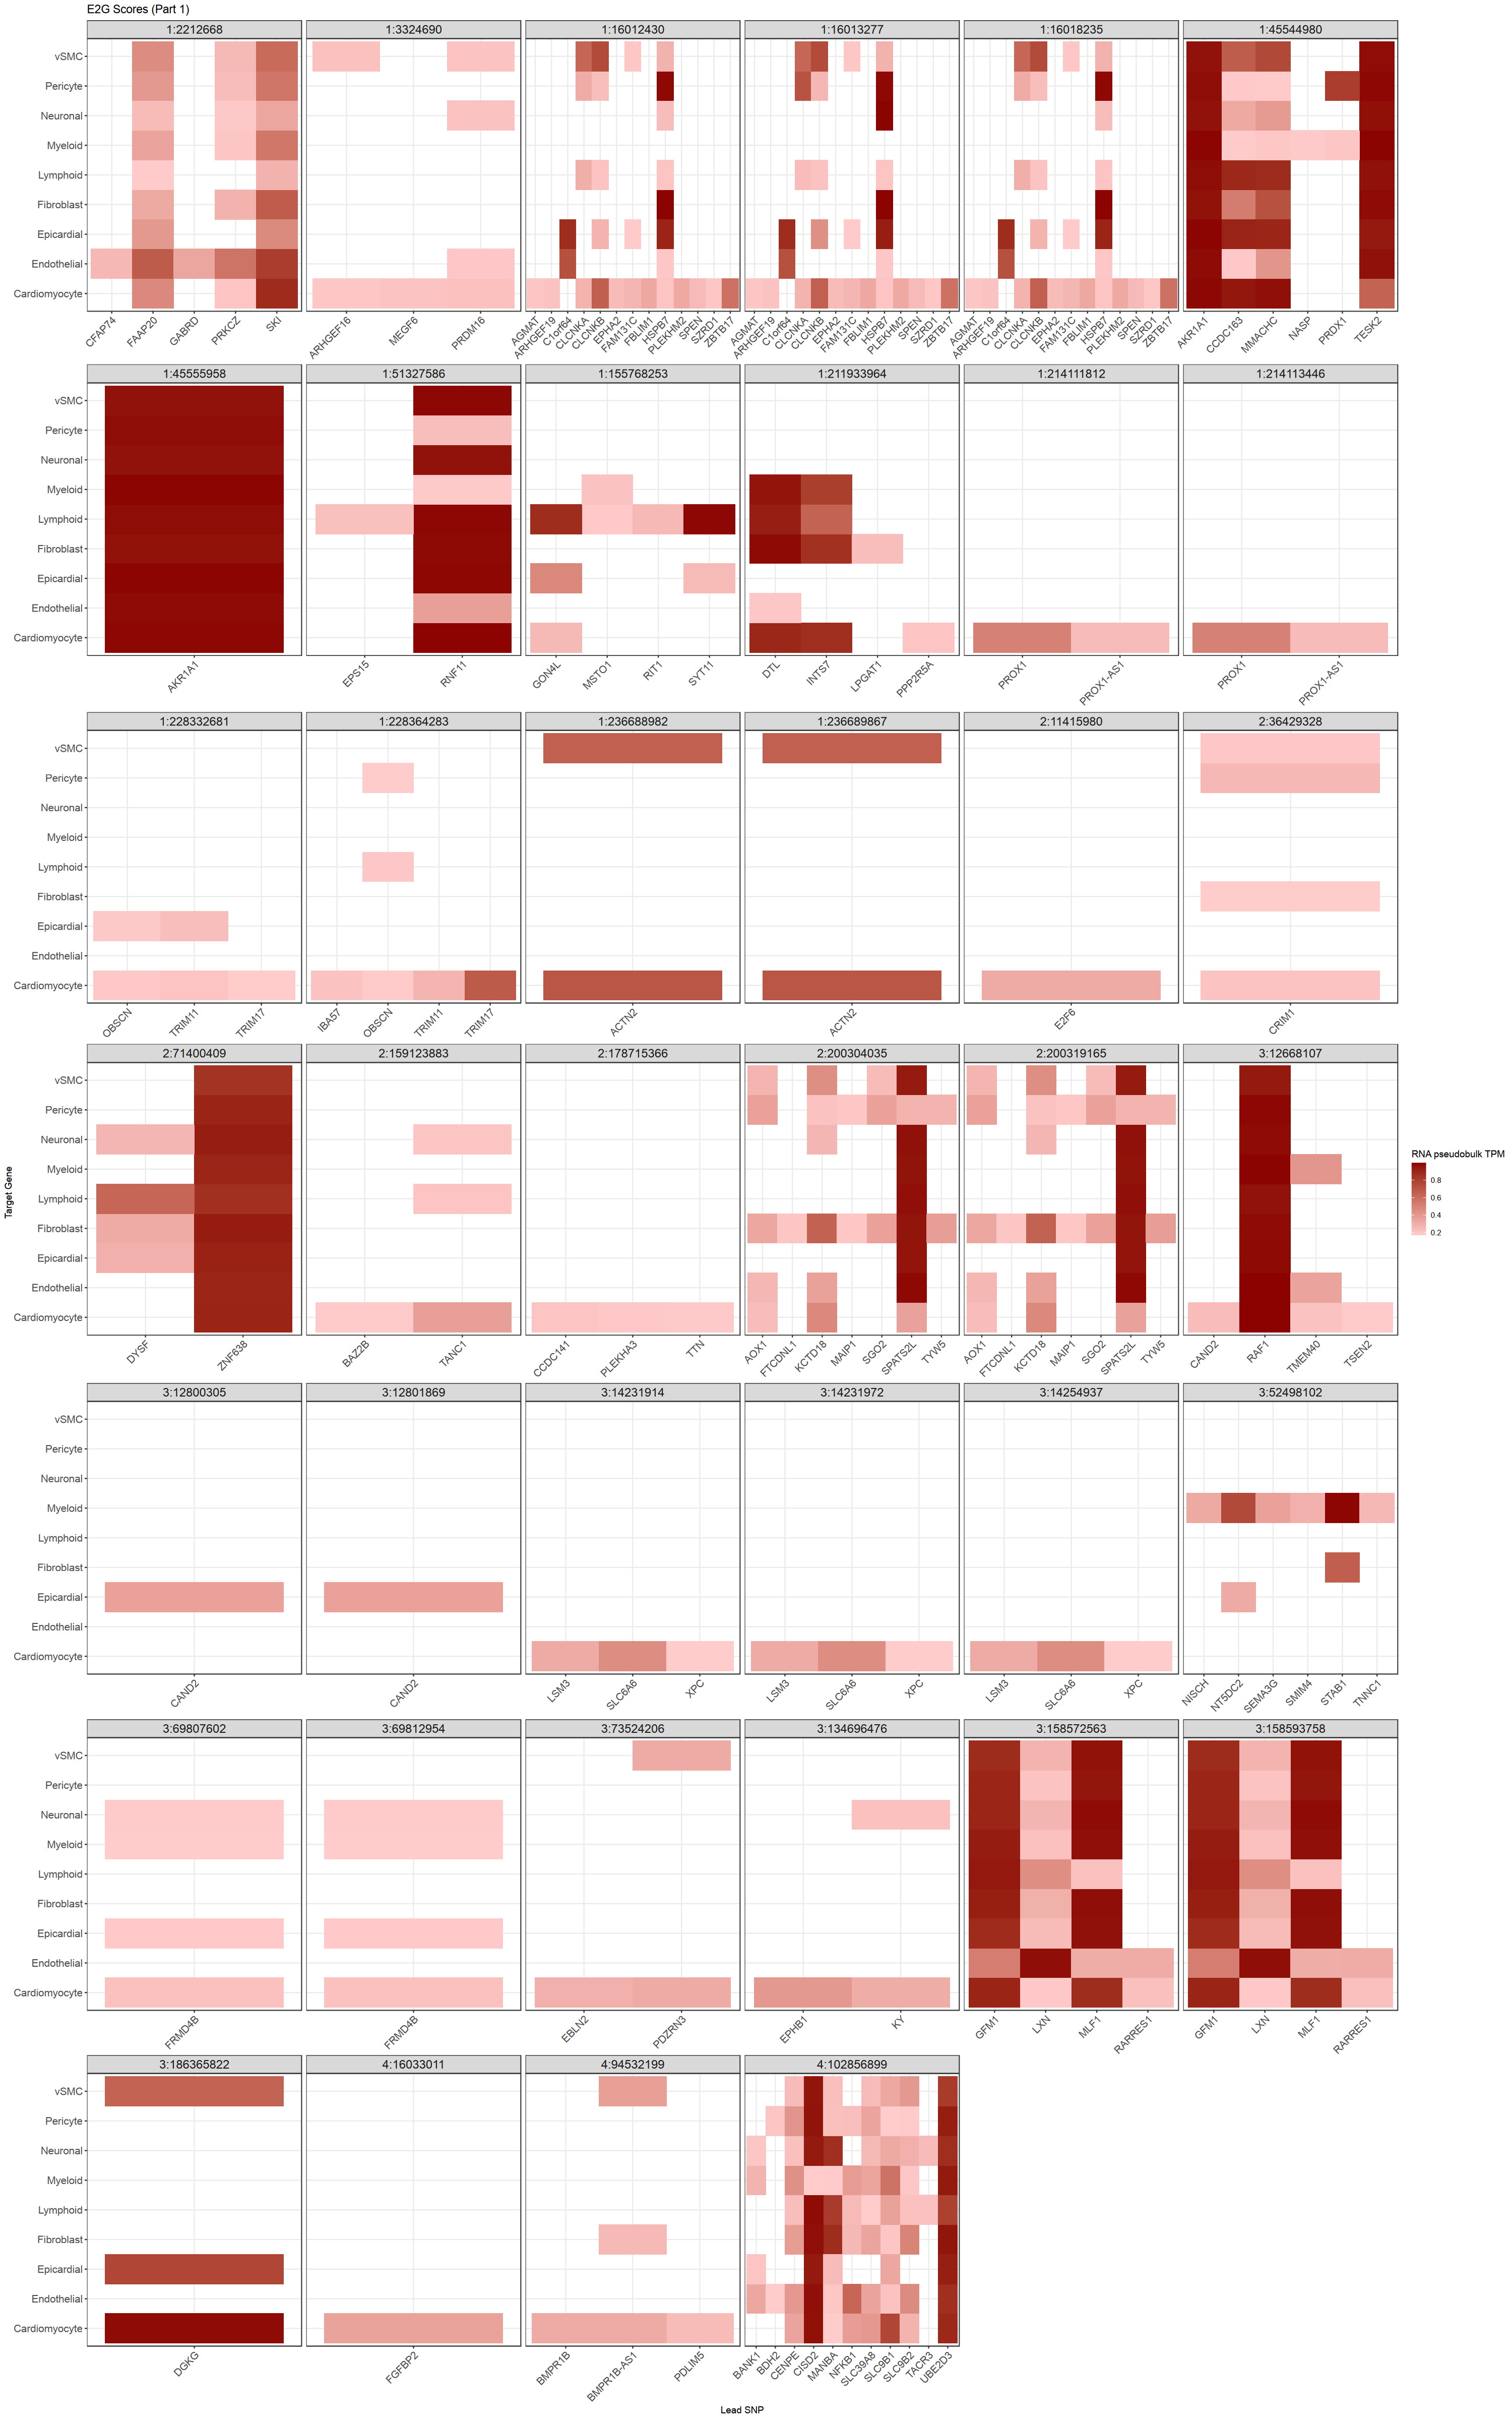

In [17]:
p1

### Produce linkage plot for HCM

In [18]:
HCM_concat_df <- concat_df[concat_df$disease == "HCM", ]
filtered_HCM_df <- filtered_df[filtered_df$disease == "HCM", ]
dim(filtered_HCM_df)

[1] 98 13

In [19]:
# reorder the chromosomes
HCM_concat_df <- HCM_concat_df %>%
  separate(lead_SNP_new, into = c("chr", "pos"), sep = ":", remove = FALSE) %>%
  mutate(
    chr = factor(chr, levels = c(as.character(1:22), "X", "Y"), ordered = TRUE),
    pos = as.numeric(pos)
  )

HCM_concat_df <- HCM_concat_df %>%
  arrange(chr, pos) %>%
  mutate(lead_SNP_new = factor(lead_SNP_new, levels = unique(lead_SNP_new)))

In [20]:
options(repr.plot.width = 25, repr.plot.height = 30)

# get unique SNPs
all_snps <- unique(HCM_concat_df$lead_SNP_new)

# split into two halves
half <- ceiling(length(all_snps) / 2)
snps_part1 <- all_snps[1:half]
snps_part2 <- all_snps[(half + 1):length(all_snps)]

# subset the data
df1 <- HCM_concat_df %>% filter(lead_SNP_new %in% snps_part1)
df2 <- HCM_concat_df %>% filter(lead_SNP_new %in% snps_part2)

# base plotting function
plot_e2g <- function(df, title_text){
  ggplot(df, aes(x = TargetGene, y = CellType, fill = `E2G.Score`)) +
    geom_tile() +
    facet_wrap(~lead_SNP_new, ncol = 6, scales = "free_x") +
    scale_fill_gradient(low = "#FFCCCC", high = "#8B0000") +
    theme_bw() +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
      axis.text.y = element_text(hjust = 1, size = 12),
      strip.text = element_text(size = 14, face = "bold")
    ) +
    labs(
      x = "Lead SNP",
      y = "Target Gene",
      fill = "RNA pseudobulk TPM",
      title = title_text
    )
}

# create plots
p2a <- plot_e2g(df1, "E2G Scores (Part 1)")
p2b <- plot_e2g(df2, "E2G Scores (Part 2)")

# save plots
ggsave("02B_HCM_GWAS_scE2G_part1.pdf", p2a, width = 25, height = 30, limitsize = FALSE)
ggsave("02B_HCM_GWAS_scE2G_part2.pdf", p2b, width = 25, height = 30, limitsize = FALSE)

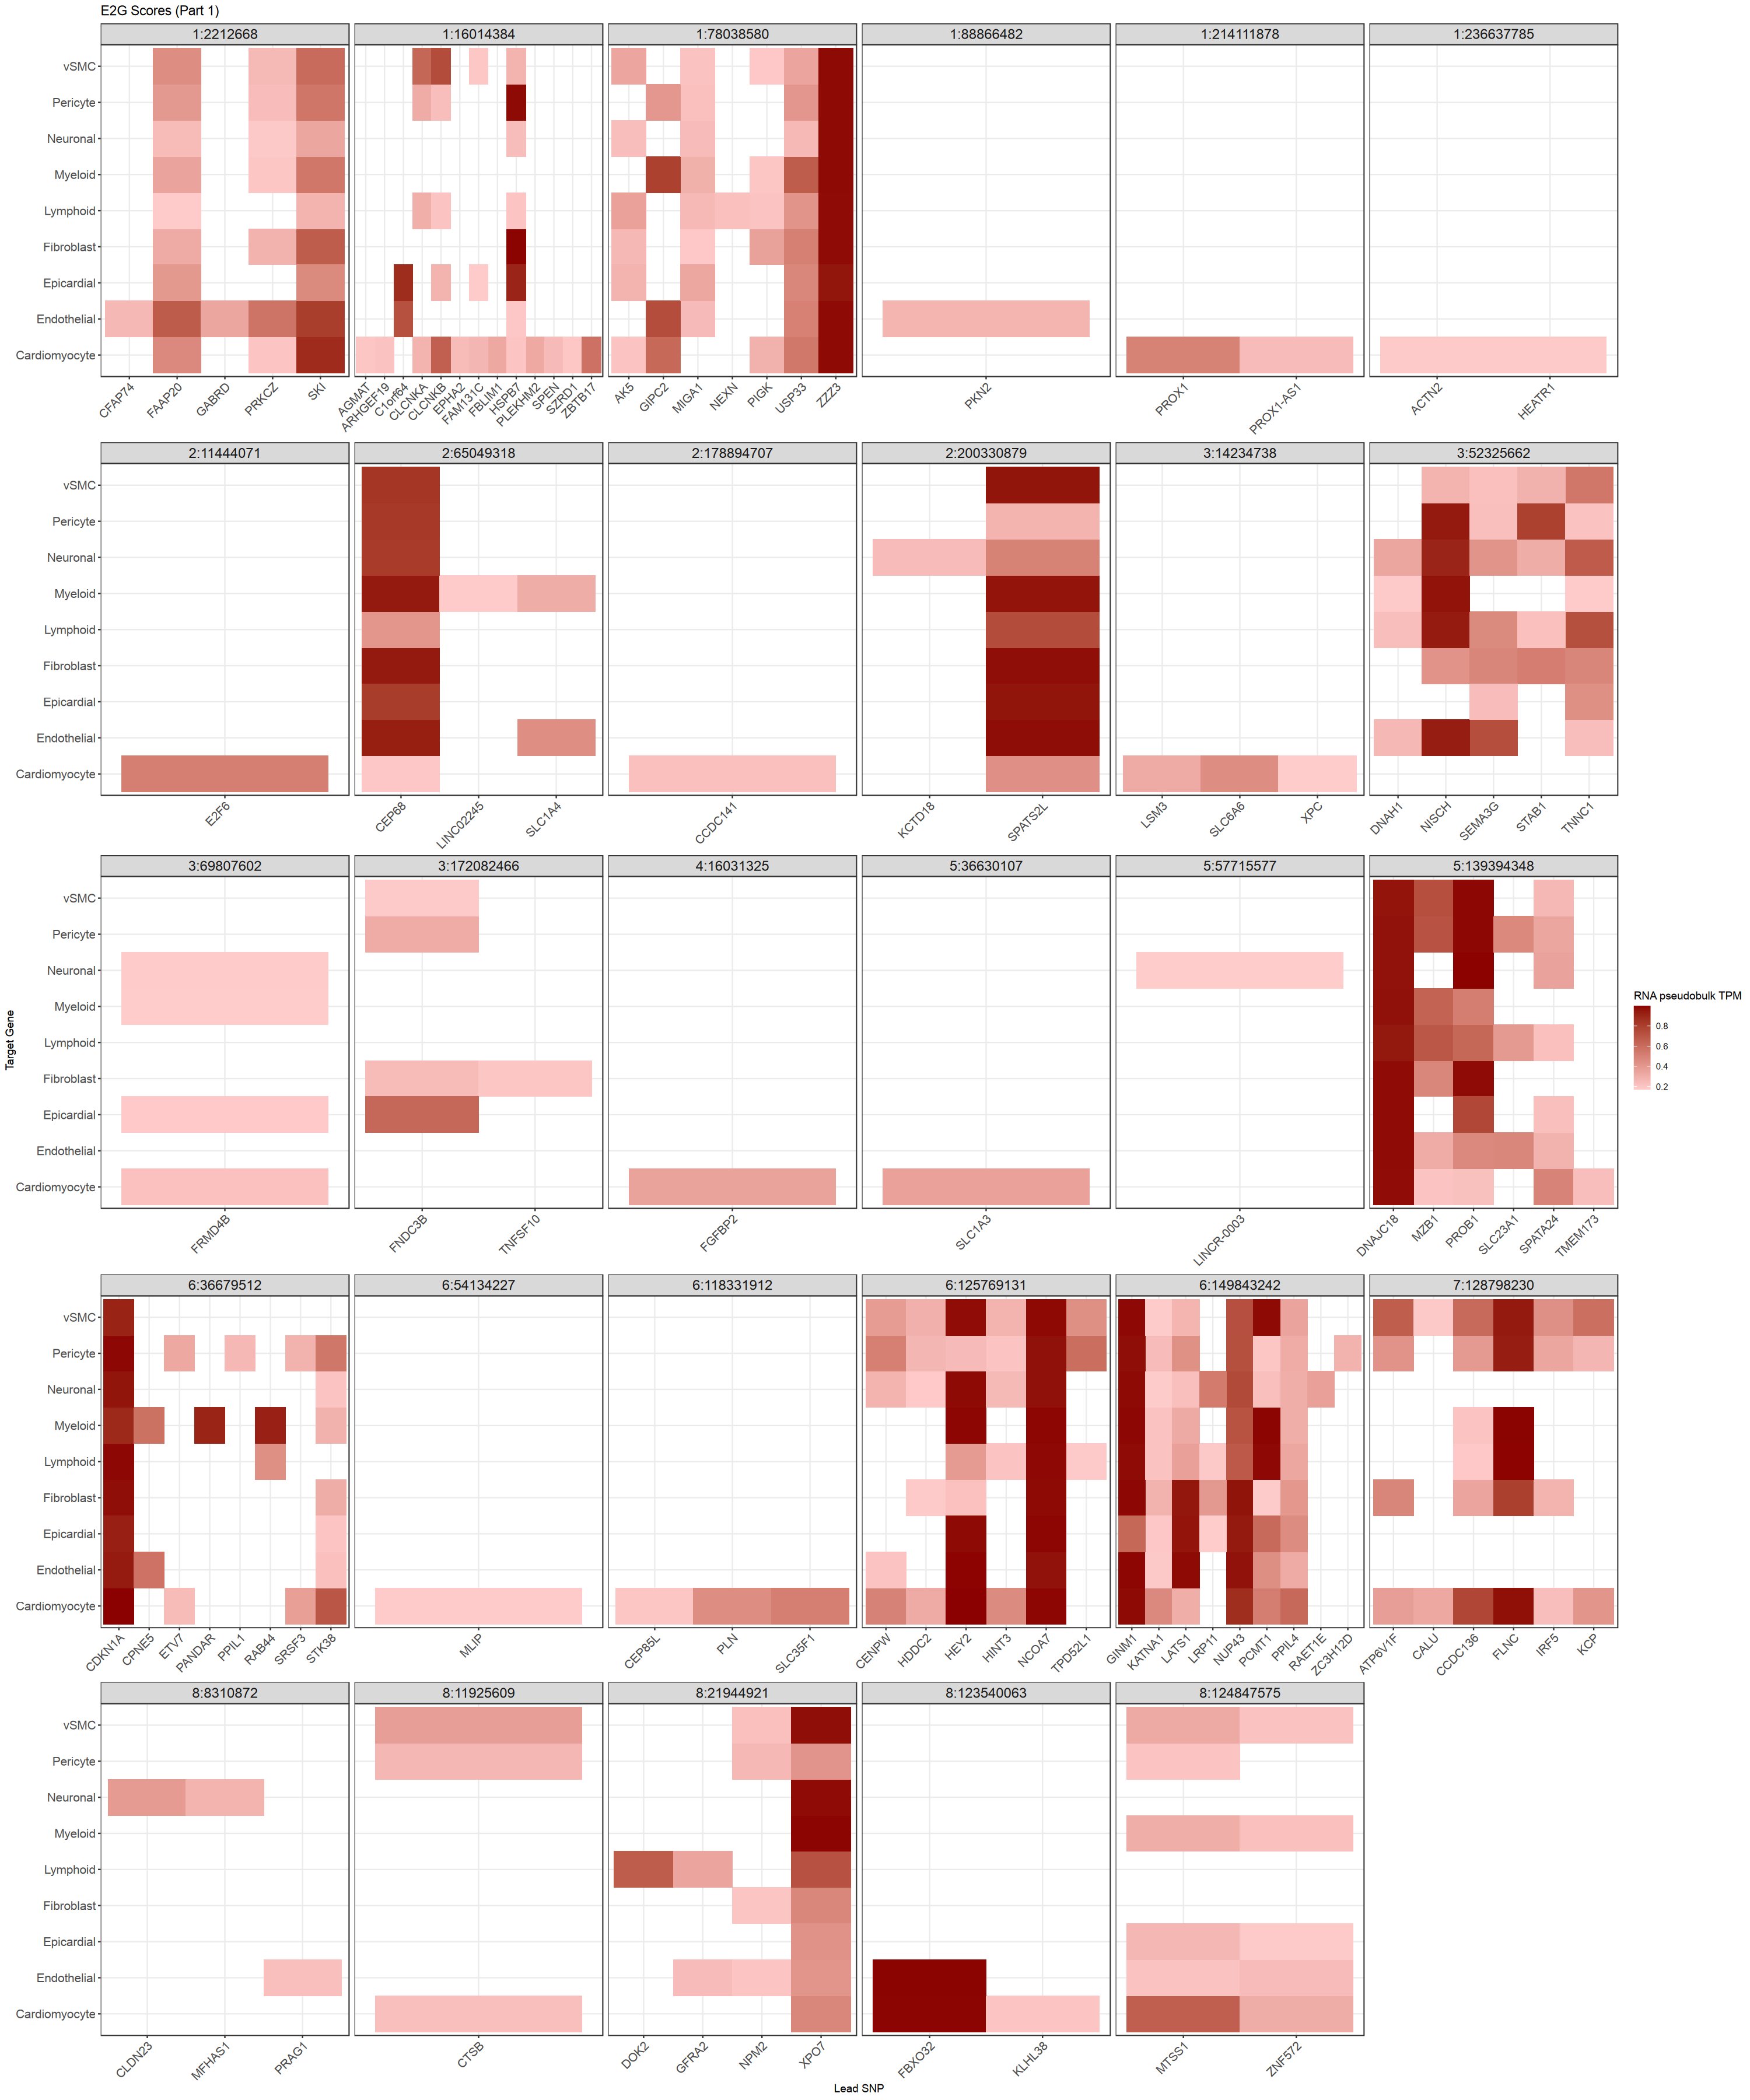

In [21]:
p2a

### Save the prioritized genes in supplemental df

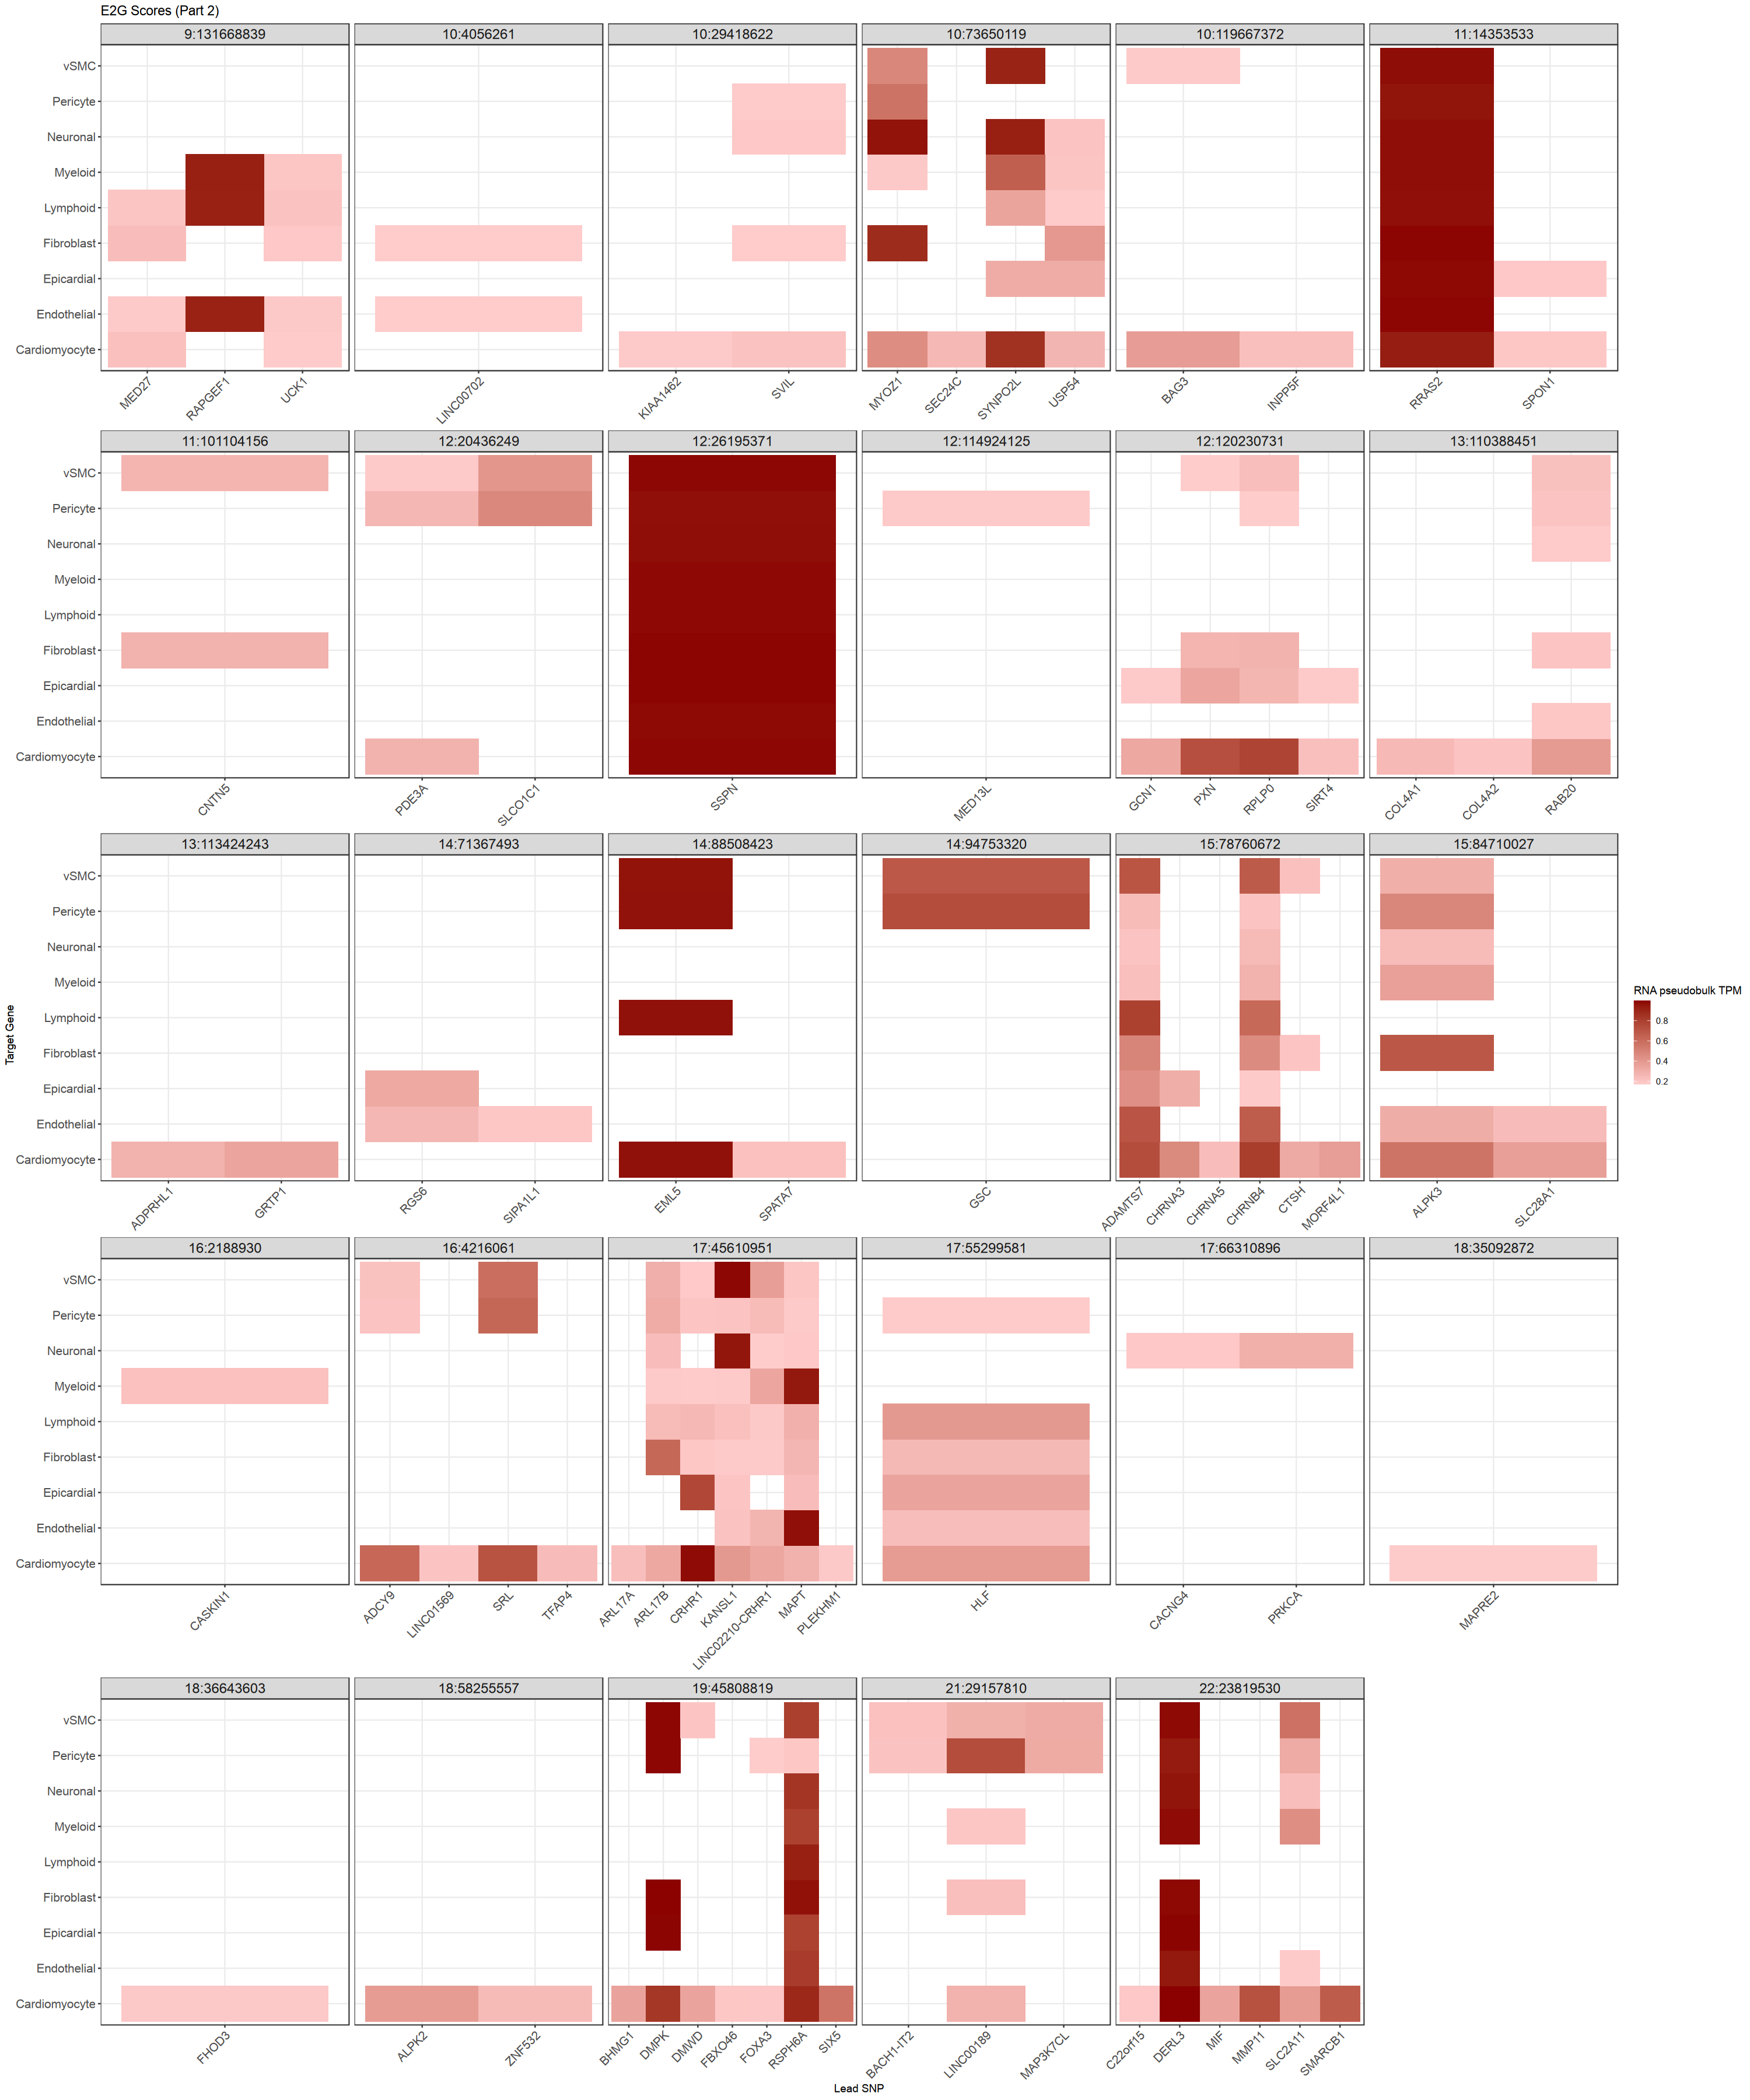

In [22]:
p2b

In [23]:
further_filtered_DCM_df <- filtered_DCM_df %>%
  rename(
    current_study_predicted_gene = TargetGene,
    original_study_gene = prioritized_gene
  ) %>%
  select(lead_SNP_new, current_study_predicted_gene, disease, original_study_gene, concordant, locus)

further_filtered_DCM_df <- further_filtered_DCM_df %>% distinct()

In [24]:
further_filtered_DCM_df %>% head()

lead_SNP_new,current_study_predicted_gene,disease,original_study_gene,concordant,locus
<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>
10:119656173,BAG3,DCM,BAG3,TRUE,BAG3_locus0
10:119656173,INPP5F,DCM,BAG3,TRUE,BAG3_locus0
10:119659975,BAG3,DCM,BAG3,TRUE,BAG3_locus0
10:119659975,INPP5F,DCM,BAG3,TRUE,BAG3_locus0
10:29428910,SVIL,DCM,SVIL,TRUE,SVIL_locus0
10:29428910,KIAA1462,DCM,SVIL,TRUE,SVIL_locus0


In [25]:
# combine lead_SNP_new if all other columns are the same

collapsed_DCM_df <- further_filtered_DCM_df %>%
  group_by(current_study_predicted_gene, disease, original_study_gene, concordant, locus) %>%
  summarise(
    lead_SNP_new = paste(unique(lead_SNP_new), collapse = ","),
    .groups = "drop"
  )

In [26]:
collapsed_DCM_df <- dplyr::select(collapsed_DCM_df, c("lead_SNP_new", "locus", "disease", 
                                    "current_study_predicted_gene", "original_study_gene", "concordant"))

In [27]:
table(collapsed_DCM_df$concordant)


FALSE  TRUE 
   56   110 

In [28]:
collapsed_DCM_df

lead_SNP_new,locus,disease,current_study_predicted_gene,original_study_gene,concordant
<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
"1:236688982,1:236689867",ACTN2_locus0,DCM,ACTN2,ACTN2,TRUE
15:78790089,ADAMTS7_locus0,DCM,ADAMTS7,ADAMTS7,TRUE
8:140614946,AGO2_locus0,DCM,AGO2,AGO2,TRUE
16:67526710,C16orf86_locus0,DCM,AGRP,C16orf86,FALSE
16:67421955,RRAD_locus0,DCM,AGRP,RRAD,FALSE
"1:45544980,1:45555958",MAST2_locus0,DCM,AKR1A1,MAST2,FALSE
18:58255557,NEDD4L_locus0,DCM,ALPK2,NEDD4L,FALSE
15:84845422,ALPK3_locus1,DCM,ALPK3,ALPK3,TRUE
4:113535350,CAMK2D_locus0,DCM,ANK2,CAMK2D,FALSE


In [29]:
collapsed_DCM_df <- collapsed_DCM_df %>%
  # extract chromosome and position from the first SNP in the list
  mutate(first_SNP = sapply(strsplit(lead_SNP_new, ","), `[`, 1)) %>%
  separate(first_SNP, into = c("chr", "pos"), sep = ":", convert = TRUE) %>%
  mutate(chr = as.numeric(gsub("X", "23", chr))) %>%  # optional: handle chrX if present
  arrange(chr, pos) %>%
  select(-chr, -pos)

In [30]:
collapsed_DCM_df

lead_SNP_new,locus,disease,current_study_predicted_gene,original_study_gene,concordant
<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
1:2212668,SKI_or_C1orf86_locus0,DCM,FAAP20,SKI_or_C1orf86,FALSE
1:2212668,SKI_or_C1orf86_locus0,DCM,SKI,SKI_or_C1orf86,FALSE
1:3324690,PRDM16_locus0,DCM,ARHGEF16,PRDM16,TRUE
1:3324690,PRDM16_locus0,DCM,PRDM16,PRDM16,TRUE
"1:16012430,1:16018235",HSPB7_locus0,DCM,C1orf64,HSPB7,FALSE
"1:16012430,1:16018235",HSPB7_locus0,DCM,CLCNKA,HSPB7,FALSE
1:16013277,HSPB7_locus0,DCM,CLCNKA,HSPB7,TRUE
1:16013277,HSPB7_locus0,DCM,HSPB7,HSPB7,TRUE
"1:45544980,1:45555958",MAST2_locus0,DCM,AKR1A1,MAST2,FALSE


In [31]:
write.csv(collapsed_DCM_df, "02B_prioritized_DCM_genes.csv")

In [32]:
table(collapsed_DCM_df$concordant)


FALSE  TRUE 
   56   110 

### perform also for HCM

In [33]:
further_filtered_HCM_df <- filtered_HCM_df %>%
  rename(
    current_study_predicted_gene = TargetGene,
    original_study_gene = prioritized_gene
  ) %>%
  select(lead_SNP_new, current_study_predicted_gene, disease, original_study_gene, concordant)

further_filtered_HCM_df <- further_filtered_HCM_df %>% distinct()

In [34]:
table(further_filtered_HCM_df$concordant)


FALSE  TRUE 
   35    63 

In [35]:
length(unique(filtered_HCM_df$lead_SNP_new))

[1] 58

In [36]:
further_filtered_HCM_df <- further_filtered_HCM_df %>%
  separate(lead_SNP_new, into = c("chr", "pos"), sep = ":", remove = FALSE) %>%
  mutate(
    chr = factor(chr, levels = c(as.character(1:22), "X", "Y"), ordered = TRUE),
    pos = as.numeric(pos)
  )

further_filtered_HCM_df <- further_filtered_HCM_df %>%
  arrange(chr, pos) %>%
  mutate(lead_SNP_new = factor(lead_SNP_new, levels = unique(lead_SNP_new)))

In [37]:
further_filtered_HCM_df

lead_SNP_new,chr,pos,current_study_predicted_gene,disease,original_study_gene,concordant
<fct>,<ord>,<dbl>,<chr>,<chr>,<chr>,<lgl>
1:2212668,1,2212668,SKI,HCM,FAAP20/SKI,TRUE
1:2212668,1,2212668,FAAP20,HCM,FAAP20/SKI,TRUE
1:16014384,1,16014384,C1orf64,HCM,HSPB7,FALSE
1:16014384,1,16014384,CLCNKA,HCM,HSPB7,FALSE
1:78038580,1,78038580,ZZZ3,HCM,DNAJB4/NEXN,FALSE
1:78038580,1,78038580,USP33,HCM,DNAJB4/NEXN,FALSE
1:88866482,1,88866482,PKN2,HCM,KYAT3/CCBL2,FALSE
1:214111878,1,214111878,PROX1,HCM,PROX1,TRUE
1:214111878,1,214111878,PROX1-AS1,HCM,PROX1,TRUE


In [38]:
write.csv(further_filtered_HCM_df, "02B_prioritized_HCM_genes.csv")